### La Fábrica Inteligente

**Contexto:** Eres el ingeniero a cargo de una flota de máquinas hidráulicas.

**Problema:** Si la máquina falla inesperadamente, la planta se detiene (pérdidas millonarias). Si haces mantenimiento preventivo demasiado pronto, gastas dinero innecesariamente.

**Datos:** Sensores en tiempo real (Temperatura, Velocidad de rotación, Torque, Desgaste de la herramienta).

**Objetivo:** Clasificación Binaria -> ¿Fallará la máquina en el próximo ciclo? (1: Sí, 0: No).

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# !pip install xgboost
from xgboost import XGBClassifier
# !pip install lightgbm
from lightgbm import LGBMClassifier

sns.set_style("whitegrid")

In [2]:
#from google.colab import files
#files.upload()

#data = pd.read_csv('Country-data.csv')

In [3]:
data = pd.read_csv('data/ai4i2020.csv')
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset

### Descripción

**AI4I 2020 Predictive Maintenance Dataset:** Es un dataset sintético pero muy realista creado por el Fraunhofer Institute para simular procesos industriales de mecanizado (fresado).

### Las Variables Predictoras (Features - Los "Sensores")

Estas son las señales físicas que alimentan al algoritmo. 

- **Type (Tipo de Producto/Calidad):**
  
    - Calidad del producto que se está fabricando: L (Low/Bajo, 50% de los casos), M (Medium/Medio, 30%), H (High/Alto, 20%).
    - Nota: Las herramientas de calidad 'L' suelen romperse más. Hay que convertir esto a números (Encoding) para el modelo.
 
- **Air temperature [K] (Temperatura del Aire):** Es la temperatura ambiente en la fábrica (en Kelvin). Normalmente alrededor de 300K (27°C).
  
- **Process temperature [K] (Temperatura del Proceso):** Es la temperatura generada en la zona de corte.
    - Importante: Si la diferencia entre la temperatura de proceso y la del aire es muy baja, indica problemas de disipación de calor.
     
- **Rotational speed [rpm] (Velocidad de Rotación):** A cuántas revoluciones por minuto gira el husillo (cabezal) de la herramienta.
  
- **Torque [Nm] (Par Motor):** La fuerza de giro aplicada.
    - Física: Normalmente, a mayor velocidad, menor torque, y viceversa ($Potencia = Torque \times Velocidad$). Si ambos son altos a la vez, es una anomalía peligrosa (sobrecarga).
 
- **Tool wear [min] (Desgaste de Herramienta):** Tiempo acumulado que la herramienta ha estado cortando.
    - Intuición: Cuanto más alto es este número, más probable es que la herramienta se rompa por fatiga.

### Las Variables "Data Leakage

Estas columnas NO deben usarse como entrada (X) para predecir el fallo general, porque son el fallo en sí mismo desglosado por tipo. Si las incluyes, el modelo tendrá un 100% de acierto artificial.

Estas columnas son útiles para el diagnóstico post-mortem, pero no como sensores predictivos:

- **TWF (Tool Wear Failure):** Fallo por desgaste (la herramienta se usó demasiado).

- **HDF (Heat Dissipation Failure):** Fallo por calor (la diferencia de temperatura fue insuficiente).

- **PWF (Power Failure):** Fallo de potencia (Producto de Torque x Velocidad excesivo).

- **OSF (Overstrain Failure):** Fallo por sobrecarga (Torque o desgaste muy altos).

- **RNF (Random Failure):** Fallos aleatorios (simulan el caos del mundo real).

### Variables identificadoras

No aportan información física predictiva:

- **UDI:** Identificador único (1, 2, 3...). El modelo podría memorizar que "la fila 50 siempre falla", lo cual no sirve para datos nuevos.

- **Product ID:** Código de serie (M14860...). Demasiado específico, mejor usar solo Type

In [4]:
data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
data.shape

(10000, 14)

## Variable Objetivo

### Variable Objetivo (Target)

**Machine failure (Fallo de Máquina):**

- Tipo: Binaria (0 o 1).

- Significado: Indica si la máquina falló en ese ciclo concreto.

- **Valor 0:** Funcionamiento normal.

- **Valor 1:** La máquina se rompió o paró.

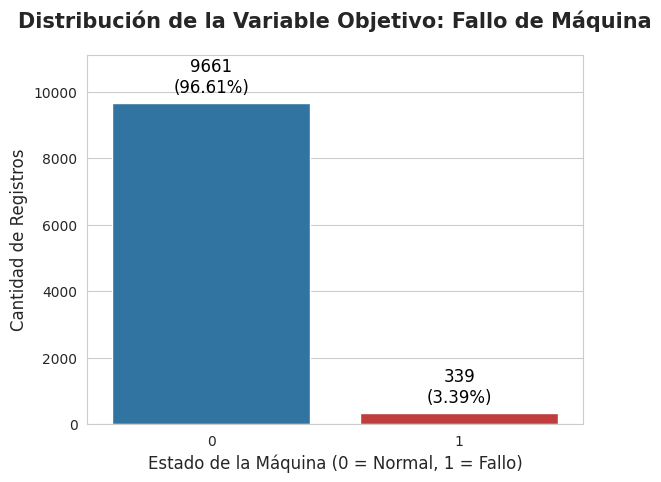

In [6]:
ax = sns.countplot(
    x='Machine failure', 
    data=data, 
    hue='Machine failure',  
    palette=['#1f77b4', '#d62728'], 
    legend=False        
)

# Títulos
plt.title('Distribución de la Variable Objetivo: Fallo de Máquina', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Estado de la Máquina (0 = Normal, 1 = Fallo)', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)

# Ajustar el techo del gráfico
# Obtenemos la altura máxima de los datos para calcular el nuevo límite
max_count = data['Machine failure'].value_counts().max()
# Le damos un 15% extra de espacio arriba para que quepan los textos
plt.ylim(0, max_count * 1.15)

# Anotaciones (Porcentajes)
total = len(data)
for p in ax.patches:
    height = p.get_height()
    # Evitamos anotar barras vacías
    if height > 0:
        percentage = f'{100 * height / total:.2f}%'
        x = p.get_x() + p.get_width() / 2
        y = height
        
        # Escribir el número y el porcentaje
        ax.annotate(f'{int(height)}\n({percentage})', 
                    (x, y), 
                    ha='center', 
                    va='bottom', 
                    fontsize=12, 
                    color='black',
                    xytext=(0, 5), 
                    textcoords='offset points')

plt.show()

In [7]:
# PASO 1: Eliminar columnas innecesarias
# Definimos las columnas que sobran
cols_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
data_clean = data.drop(columns=cols_to_drop)

In [8]:
# PASO 2: Verificar valores nulos
print("--- Recuento de Valores Nulos ---")
print(data_clean.isnull().sum())

--- Recuento de Valores Nulos ---
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64


In [9]:
# PASO 3: Convertir 'Type' a numérico

# Diccionario de mapeo: Definimos qué número corresponde a cada letra
# L = Low (Baja calidad), M = Medium, H = High (Alta calidad)
quality_map = {'L': 1, 'M': 2, 'H': 3}

# Aplicamos el cambio
data_clean['Type'] = data_clean['Type'].map(quality_map)

print("Verificación de transformación:")
print(data_clean['Type'].value_counts())
print("\nAhora todas las columnas son numéricas:")
data_clean.head()

Verificación de transformación:
Type
1    6000
2    2997
3    1003
Name: count, dtype: int64

Ahora todas las columnas son numéricas:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


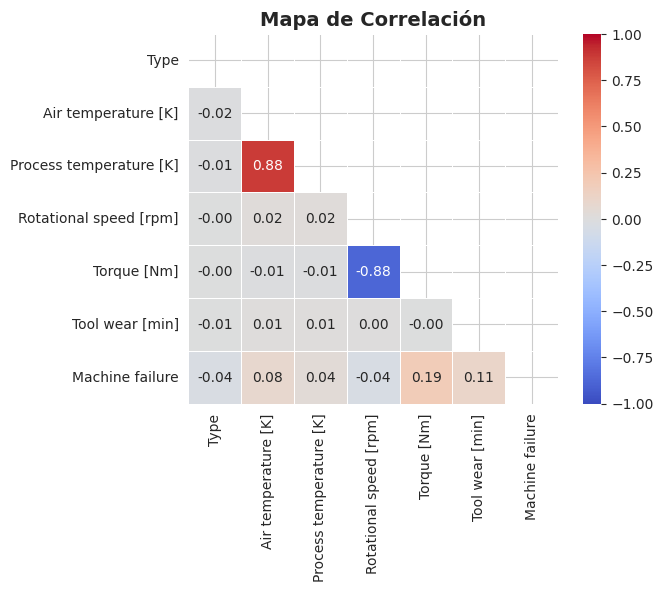

In [10]:
# PASO 4: Calcular la correlación (incluye 'Type')
corr = data_clean.corr()

# Máscara para el triángulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))
# Mapa de Calor (Heatmap)
sns.heatmap(corr, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmax=1, vmin=-1, 
            linewidths=0.5, 
            square=True)

plt.title('Mapa de Correlación', fontsize=14, fontweight='bold')
plt.show()

In [11]:
# Paso 5 Definir X (Variables predictoras) e y (Objetivo)
X = data_clean.drop('Machine failure', axis=1)
y = data_clean['Machine failure']

In [12]:
# Paso 6 Dividir en Train (Entrenamiento) y Test (Prueba)

# stratify=y: Asegura que haya la misma proporción de fallos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print(f"Entrenamiento (X_train): {X_train.shape[0]} filas")
print(f"Test (X_test): {X_test.shape[0]} filas")

Entrenamiento (X_train): 8000 filas
Test (X_test): 2000 filas


In [13]:
# Paso 7: Validación Cruzada Estratificada
# Dividimos los datos en 5 partes (folds).
# 'Stratified' Asegura que haya la misma proporción de fallos
stratKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
# Paso 8: Diccionario de Hiperparámetros
# El GridSearch probará TODAS las combinaciones posibles de estos valores.
dict_params = {
    "n_estimators": [100, 200],              # Número de árboles
    "max_depth": [5, 10, None],              # Profundidad (evitar overfitting)
    "criterion": ["gini", "entropy"],        # Cómo mide la impureza
    "max_features": ["sqrt"],                # Cuántas variables mira cada árbol
    "bootstrap": [True],                     # Muestreo con reemplazo
    # Penaliza al modelo más fuerte si se equivoca en una Falla (1) que si se equivoca en un Normal (0)
    "class_weight": ["balanced", None],      # ¡CLAVE! Para arreglar el desbalance
    "max_samples": [0.6, 0.8]                # Cuantos datos usa cada árbol
}

#### Verdadero Positivo (Acierto Crítico):

- Realidad: La máquina iba a romperse.

- Predicción: El modelo paró la máquina.

- Impacto: Salvaste la producción. Has evitado un desastre.

#### Verdadero Negativo (Funcionamiento Normal):

- Realidad: La máquina estaba bien.

- Predicción: El modelo dejó que siguiera funcionando.

- Impacto: Eficiencia. Todo fluye correctamente.

#### Falso Positivo (La Falsa Alarma - Error Tipo I):

- Realidad: La máquina estaba perfecta.

- Predicción: El modelo gritó "¡Falla!" y paró la línea.

- Impacto: Coste Económico. Pierdes tiempo revisando una máquina que estaba bien, pero no es peligroso.

#### Falso Negativo (El Desastre Silencioso - Error Tipo II):

- Realidad: La máquina se estaba rompiendo.

- Predicción: El modelo dijo "Todo está bien".

- Impacto: Catástrofe. La máquina explota o se rompe sin aviso. En ingeniería, este es el error que obsesivamente queremos evitar.

### OPCIÓN 1: Recall (Sensibilidad)

**Opción 1: Recall (Sensibilidad)**

Metrica ideal si este modelo es para una central nuclear o un avión.

Filosofía: "Prohibido terminantemente que se rompa una máquina sin aviso".

Lo que hace: Le dice al modelo: Tu única misión es encontrar TODAS las fallas. No me importa si das 50 falsas alarmas, pero no te puedes saltar ni una falla real.

El Riesgo: El modelo puede volverse "paranoico" y decir que todo va a fallar. Tendrás muchas paradas de mantenimiento innecesarias (muchos Falsos Positivos).

Cuándo usarla: Cuando el costo de un Falso Negativo (rotura) es infinito o mortal.

In [15]:
# Paso 9: Entrenar con Búsqueda de Rejilla (GridSearch)
model_RF = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=dict_params,
    cv=stratKF,               # Usamos los 5 folds estratificados
    refit=True,               # Al final, reentrena el mejor modelo con TODOS los datos
    verbose=1,                # Para ver el progreso en pantalla
    n_jobs=-1,                # Usar todos los núcleos del procesador (paralelizar)
    return_train_score=True,
    scoring="recall"              # Optimizamos F1-Score (vital para desbalance)
)

print("--- Iniciando Búsqueda de Hiperparámetros ---")

model_RF.fit(X_train, y_train)

print(f"\nMejores parámetros encontrados: {model_RF.best_params_}")
print(f"Mejor F1-Score en validación: {model_RF.best_score_:.4f}")

--- Iniciando Búsqueda de Hiperparámetros ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores parámetros encontrados: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.8, 'n_estimators': 200}
Mejor F1-Score en validación: 0.8338


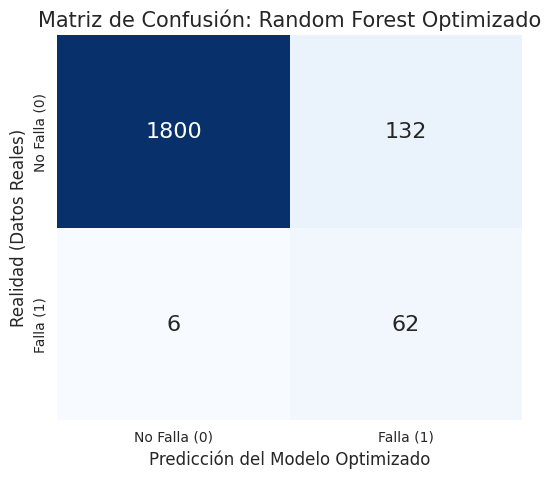

--- Reporte del Modelo Optimizado ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.32      0.91      0.47        68

    accuracy                           0.93      2000
   macro avg       0.66      0.92      0.72      2000
weighted avg       0.97      0.93      0.95      2000



In [16]:
# Paso 10: Predecir usando el MEJOR modelo encontrado

y_pred_best = model_RF.predict(X_test)

# Generar Matriz de Confusión
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})

plt.xlabel('Predicción del Modelo Optimizado', fontsize=12)
plt.ylabel('Realidad (Datos Reales)', fontsize=12)
plt.title('Matriz de Confusión: Random Forest Optimizado', fontsize=15)
plt.xticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.yticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.show()

# Informe final
print("--- Reporte del Modelo Optimizado ---")
print(classification_report(y_test, y_pred_best))

### OPCIÓN 2: Precisión

**Opción 2: Precision (Precisión)**

Filosofía: "Solo avísame si estás 100% seguro, porque enviar al técnico me cuesta dinero".

Lo que hace: Minimiza las falsas alarmas. Si el modelo dice "Falla", es porque es verdad.

El Riesgo: Se comerá muchas fallas reales (muchos Falsos Negativos) porque ante la duda, prefiere callar.

Cuándo usarla: Cuando el costo de la Falsa Alarma (inspección) es muy alto y la rotura no es grave.

In [17]:
# Paso 9: Entrenar con Búsqueda de Rejilla (GridSearch)
model_RF = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=dict_params,
    cv=stratKF,               # Usamos los 5 folds estratificados
    refit=True,               # Al final, reentrena el mejor modelo con TODOS los datos
    verbose=1,                # Para ver el progreso en pantalla
    n_jobs=-1,                # Usar todos los núcleos del procesador (paralelizar)
    return_train_score=True,
    scoring="precision"              # Optimizamos F1-Score (vital para desbalance)
)

print("--- Iniciando Búsqueda de Hiperparámetros ---")

model_RF.fit(X_train, y_train)

print(f"\nMejores parámetros encontrados: {model_RF.best_params_}")
print(f"Mejor F1-Score en validación: {model_RF.best_score_:.4f}")

--- Iniciando Búsqueda de Hiperparámetros ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores parámetros encontrados: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.6, 'n_estimators': 200}
Mejor F1-Score en validación: 0.9447


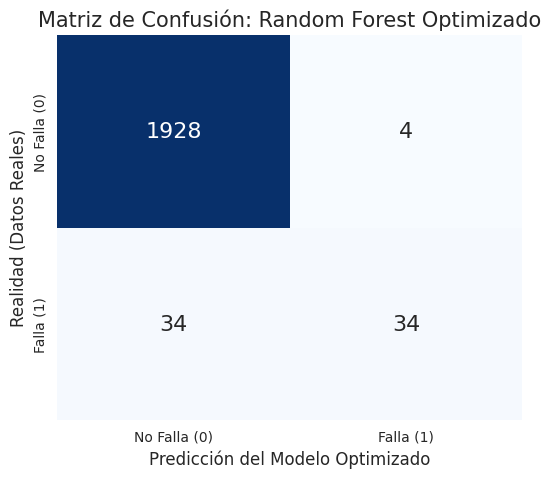

--- Reporte del Modelo Optimizado ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.89      0.50      0.64        68

    accuracy                           0.98      2000
   macro avg       0.94      0.75      0.82      2000
weighted avg       0.98      0.98      0.98      2000



In [18]:
# Paso 10: Predecir usando el MEJOR modelo encontrado

y_pred_best = model_RF.predict(X_test)

# Generar Matriz de Confusión
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})

plt.xlabel('Predicción del Modelo Optimizado', fontsize=12)
plt.ylabel('Realidad (Datos Reales)', fontsize=12)
plt.title('Matriz de Confusión: Random Forest Optimizado', fontsize=15)
plt.xticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.yticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.show()

#  Informe final
print("--- Reporte del Modelo Optimizado ---")
print(classification_report(y_test, y_pred_best))

### Opción 3: F1-Score

**Opción 3: F1-Score - "El Equilibrio Diplomático"**

Es la media armónica entre las dos anteriores.

Filosofía: "Quiero detectar la mayoría de las fallas, pero sin volver loco al equipo de mantenimiento con falsas alarmas".

Lo que hace: Trata de mantener el Recall y la Precision altos a la vez.

Cuándo usarla: Es el estándar "seguro" cuando no tienes los costos en dólares exactos. Trata a los dos errores como igualmente malos.

In [19]:
# Paso 9: Entrenar con Búsqueda de Rejilla (GridSearch)
model_RF = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=dict_params,
    cv=stratKF,               # Usamos los 5 folds estratificados
    refit=True,               # Al final, reentrena el mejor modelo con TODOS los datos
    verbose=1,                # Para ver el progreso en pantalla
    n_jobs=-1,                # Usar todos los núcleos del procesador (paralelizar)
    return_train_score=True,
    scoring="f1"              # Optimizamos F1-Score (vital para desbalance)
)

print("--- Iniciando Búsqueda de Hiperparámetros ---")

model_RF.fit(X_train, y_train)

print(f"\nMejores parámetros encontrados: {model_RF.best_params_}")
print(f"Mejor F1-Score en validación: {model_RF.best_score_:.4f}")

--- Iniciando Búsqueda de Hiperparámetros ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores parámetros encontrados: {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.8, 'n_estimators': 100}
Mejor F1-Score en validación: 0.6698


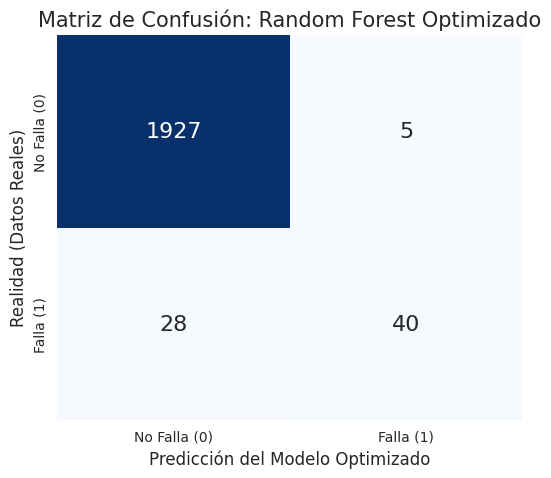

--- Reporte del Modelo Optimizado ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.59      0.71        68

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



In [20]:
# Paso 10: Predecir usando el MEJOR modelo encontrado

y_pred_best = model_RF.predict(X_test)

# Generar Matriz de Confusión
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})

plt.xlabel('Predicción del Modelo Optimizado', fontsize=12)
plt.ylabel('Realidad (Datos Reales)', fontsize=12)
plt.title('Matriz de Confusión: Random Forest Optimizado', fontsize=15)
plt.xticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.yticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.show()

# Informe final
print("--- Reporte del Modelo Optimizado ---")
print(classification_report(y_test, y_pred_best))

/tmp/ipykernel_10717/2902538094.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


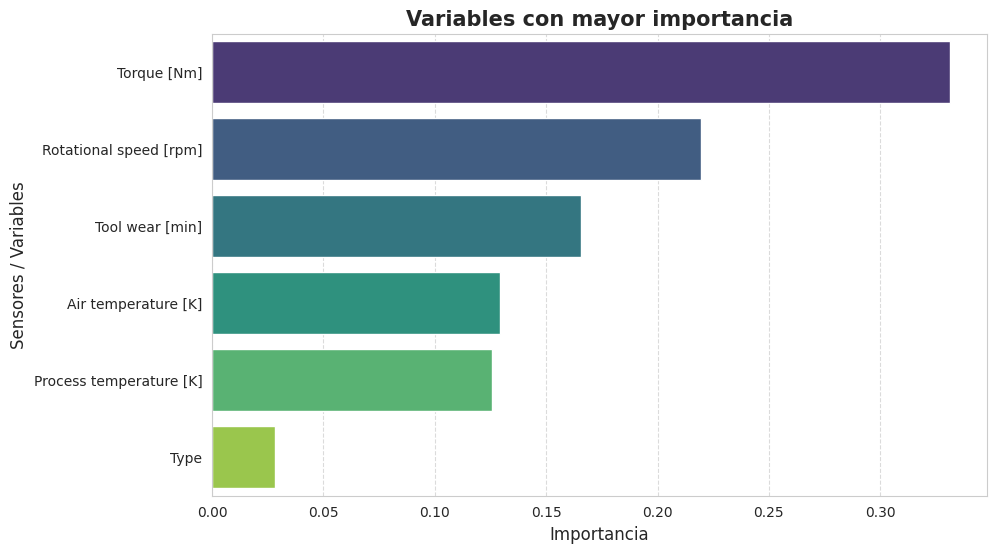

Ranking de Importancia:
                   Feature  Importance
4              Torque [Nm]    0.331345
3   Rotational speed [rpm]    0.219648
5          Tool wear [min]    0.165709
1      Air temperature [K]    0.129258
2  Process temperature [K]    0.125650
0                     Type    0.028390


In [24]:
# Importancia de las variables predictoras

best_rf_model = model_RF.best_estimator_

# Obtener la importancia de cada variable
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

# Crear un DataFrame para ordenar los datos
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False) # Ordenar de mayor a menor


plt.figure(figsize=(10, 6))

sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')

plt.title('Variables con mayor importancia', fontsize=15, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Sensores / Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Rejilla vertical suave
plt.show()

# Mostrar los valores exactos en texto
print("Ranking de Importancia:")
print(feature_imp_df)

## Conclusiones

#### 1. El Escenario "Precision" (Ahorro de gastos en mantenimiento)

Filosofía: "Solo hablo si estoy segurísimo".

El Dato Clave: Recall del 50%.

Traducción a Ingeniería:

- Había 68 máquinas rotas.

- El modelo detectó 34.


Análisis de Parámetros: Aunque el class_weight es balanced, el modelo se inclinó hacia la precisión

**Veredicto:** Inaceptable para Prevención de Fallos. Detecta muy pocos fallos y expone la producción a un alto riesgo..

#### 2. El Escenario "Recall" (Prioriza la Seguridad)
Filosofía: "Que no se me escape casi ningún fallo".

El Dato Clave: Recall del 91% (Subió muchísimo) pero Precisión del 32% (Bajó muchísimo).

El Costo: La precisión es 0.32. Significa que de cada 3 veces que suena la alarma, 2 son mentira (Falsas Alarmas).

Análisis de Parámetros:

- class_weight: 'balanced'. Forzó al modelo a aprender mejor la clase minoritaria (Fallo)

- max_depth: 5. Árboles cortos. hace que los árboles sean simples y generalicen bien para encontrar la clase minoritaria, lo que suele favorecer el Recall.

**Veredicto:** El Mejor Modelo para sistemas CRÍTICOS. Aceptamos muchas falsas alarmas para minimizar la probabilidad de que una máquina falle inesperadamente.

#### 3. El Escenario "F1-Score" (Equilibrado)
Filosofía: "Intento hacerlo bien en general, sin arriesgar mucho".

El Dato Clave: Recall del 59%. F1 Score: 0.71

Traducción a Ingeniería:

- Había 68 máquinas rotas.

- El modelo detectó solo 40.


**Veredicto:** El Mejor Modelo para un Equilibrio Matemático y eficiencia de mantenimiento

**Conclusión Final**
- La métrica importa más que el algoritmo: Usamos el mismo Random Forest, los mismos datos, pero solo cambiando scoring, el resultado pasó de ser un desastre de seguridad (Precision) a un sistema robusto (Recall).

- El precio de la seguridad: Para subir el Recall del 59% al 91%, tuvimos que aceptar que la Precisión cayera del 89% al 32%. No existe el modelo perfecto, existe el modelo que se ajusta al presupuesto de riesgo de la empresa.

## XGBOOST

In [45]:
cols_to_clean = X_train.columns

# 2. Creamos un diccionario de mapeo con los nombres limpios
renaming_map = {
    'Rotational speed [rpm]': 'Rotational_Speed_rpm',
    'Torque [Nm]': 'Torque_Nm',
    'Air temperature [K]': 'Air_Temperature_K',
    'Process temperature [K]': 'Process_Temperature_K',
    'Tool wear [min]': 'Tool_Wear_min'
}

# 3. Aplicamos el renombramiento a X_train y X_test
X_train.rename(columns=renaming_map, inplace=True)
X_test.rename(columns=renaming_map, inplace=True)

# Verificación de los nuevos nombres
print("Nombres de columnas actualizados para XGBoost/LightGBM:")
print(X_train.columns)

Nombres de columnas actualizados para XGBoost/LightGBM:
Index(['Type', 'Air_Temperature_K', 'Process_Temperature_K',
       'Rotational_Speed_rpm', 'Torque_Nm', 'Tool_Wear_min'],
      dtype='object')


In [46]:
# PASO 8: Diccionario de Hiperparámetros para XGBoost
# Se ajustan los parámetros clave para el rendimiento y manejo del desbalance.
weight_ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

dict_params_xgb = {
    "n_estimators": [100, 200],          # Número de árboles
    "max_depth": [5, 10],                # Profundidad máxima
    "learning_rate": [0.1, 0.05],        # Paso de aprendizaje
    # Penaliza la clase positiva (1: Fallo), crucial para datos desbalanceados
    # Este valor se calcula como (Total Clases 0 / Total Clases 1)
    "scale_pos_weight": [weight_ratio],
    "colsample_bytree": [0.7, 0.9],      # Fracción de columnas a muestrear
}

In [51]:
# PASO 9: Entrenar con Búsqueda de Rejilla (GridSearch)
model_XGB = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=dict_params_xgb,
    cv=stratKF,
    refit=True,
    verbose=1,
    n_jobs=-1,
    scoring="f1" # Optimizamos F1-Score
)

In [52]:
# PASO 10 Entrenar el modelo
model_XGB.fit(X_train, y_train)

print(f"\nMejores parámetros encontrados (XGBoost): {model_XGB.best_params_}")
print(f"Mejor F1-Score en validación (XGBoost): {model_XGB.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Mejores parámetros encontrados (XGBoost): {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'scale_pos_weight': 28.52029520295203}
Mejor F1-Score en validación (XGBoost): 0.7581


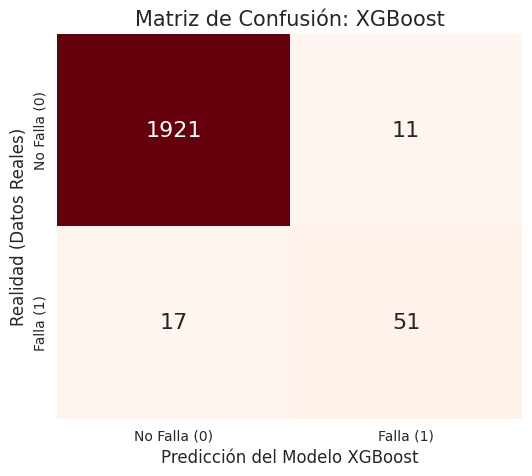

Modelo XGBoost
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.82      0.75      0.78        68

    accuracy                           0.99      2000
   macro avg       0.91      0.87      0.89      2000
weighted avg       0.99      0.99      0.99      2000



In [53]:
# PASO 11: Predecir y Evaluar el MEJOR modelo XGBoost
y_pred_xgb_best = model_XGB.predict(X_test)
cm_xgb_best = confusion_matrix(y_test, y_pred_xgb_best)

# Matriz de Confusión XGBoost 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_best, annot=True, fmt='d', cmap='Reds', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicción del Modelo XGBoost', fontsize=12)
plt.ylabel('Realidad (Datos Reales)', fontsize=12)
plt.title('Matriz de Confusión: XGBoost', fontsize=15)
plt.xticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.yticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.show()

print("Modelo XGBoost")
print(classification_report(y_test, y_pred_xgb_best))

/tmp/ipykernel_10717/838366607.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_xgb_df, palette='Reds')


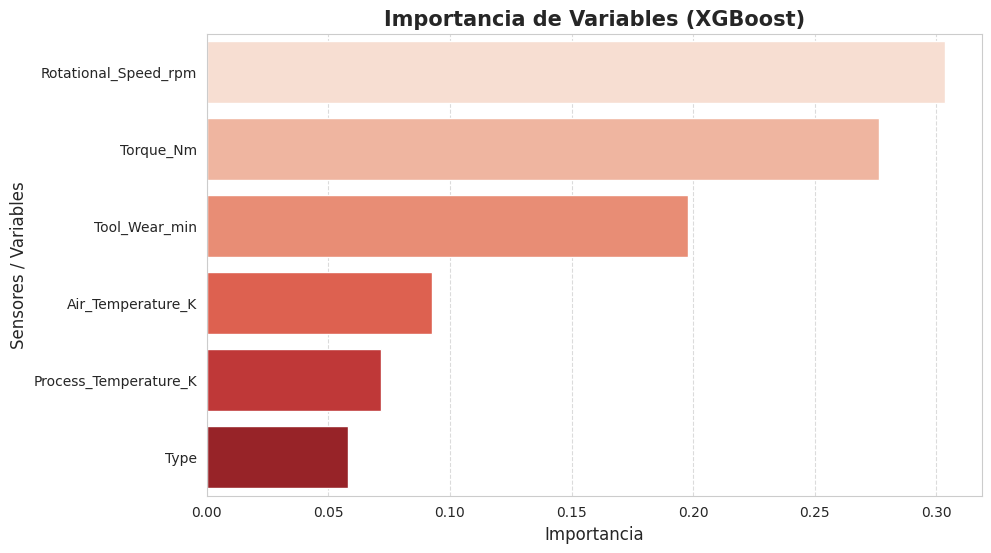


Ranking de Importancia (XGBoost):
                 Feature  Importance
3   Rotational_Speed_rpm    0.303626
4              Torque_Nm    0.276297
5          Tool_Wear_min    0.197772
1      Air_Temperature_K    0.092549
2  Process_Temperature_K    0.071653
0                   Type    0.058102


In [54]:
# Importancia de las variables predictoras (XGBoost)
best_xgb_model = model_XGB.best_estimator_
importances_xgb = best_xgb_model.feature_importances_
feature_imp_xgb_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_xgb_df, palette='Reds')
plt.title('Importancia de Variables (XGBoost)', fontsize=15, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Sensores / Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\nRanking de Importancia (XGBoost):")
print(feature_imp_xgb_df)

## LIGHTGBM

In [55]:
# PASO 8: Diccionario de Hiperparámetros para LightGBM
dict_params_lgbm = {
    "n_estimators": [100, 200],          # Número de árboles
    "max_depth": [5, 10],                # Profundidad
    "learning_rate": [0.1, 0.05],        # Paso de aprendizaje
    "num_leaves": [20, 31],              # Número de hojas en cada árbol
    "colsample_bytree": [0.7, 0.9],
    # Alternativa simple para manejar desbalance:
    "class_weight": ['balanced', None]
}

In [56]:
# PASO 9: Entrenar con Búsqueda de Rejilla (GridSearch)
model_LGBM = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1), # verbose=-1 para suprimir mensajes
    param_grid=dict_params_lgbm,
    cv=stratKF,
    refit=True,
    verbose=1,
    n_jobs=-1,
    scoring="f1" # Optimizamos F1-Score
)

In [57]:
# PASO 10 Entrenar el modelo
model_LGBM.fit(X_train, y_train)

print(f"\nMejores parámetros encontrados (LightGBM): {model_LGBM.best_params_}")
print(f"Mejor F1-Score en validación (LightGBM): {model_LGBM.best_score_:.4f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits

Mejores parámetros encontrados (LightGBM): {'class_weight': None, 'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 20}
Mejor F1-Score en validación (LightGBM): 0.7570


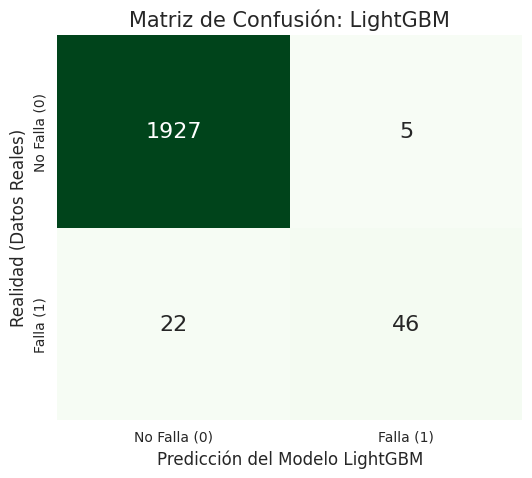

Modelo LightGBM
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.68      0.77        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.88      2000
weighted avg       0.99      0.99      0.99      2000



In [59]:
# PASO 10: Predecir y Evaluar el MEJOR modelo LightGBM
y_pred_lgbm_best = model_LGBM.predict(X_test)
cm_lgbm_best = confusion_matrix(y_test, y_pred_lgbm_best)

# Matriz de Confusión LightGBM 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgbm_best, annot=True, fmt='d', cmap='Greens', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicción del Modelo LightGBM', fontsize=12)
plt.ylabel('Realidad (Datos Reales)', fontsize=12)
plt.title('Matriz de Confusión: LightGBM', fontsize=15)
plt.xticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.yticks([0.5, 1.5], ['No Falla (0)', 'Falla (1)'])
plt.show()

print("Modelo LightGBM")
print(classification_report(y_test, y_pred_lgbm_best))

/tmp/ipykernel_10717/2723022744.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_lgbm_df, palette='Greens')


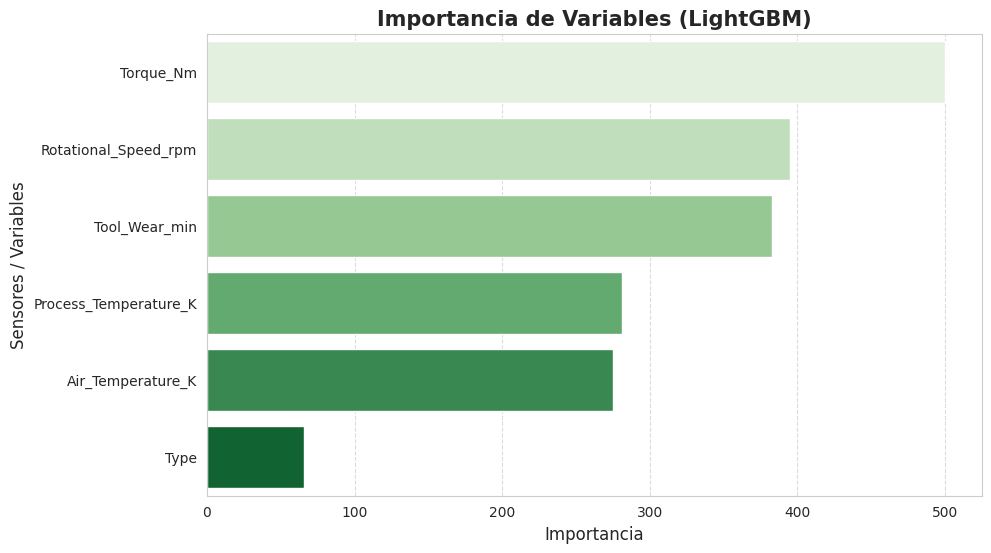


Ranking de Importancia (LightGBM):
                 Feature  Importance
4              Torque_Nm         500
3   Rotational_Speed_rpm         395
5          Tool_Wear_min         383
2  Process_Temperature_K         281
1      Air_Temperature_K         275
0                   Type          66


In [60]:
# Importancia de las variables predictoras (LightGBM)
best_lgbm_model = model_LGBM.best_estimator_
importances_lgbm = best_lgbm_model.feature_importances_
feature_imp_lgbm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_lgbm
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_lgbm_df, palette='Greens')
plt.title('Importancia de Variables (LightGBM)', fontsize=15, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Sensores / Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\nRanking de Importancia (LightGBM):")
print(feature_imp_lgbm_df)

## COMPARACIÓN DE MODELOS


--- TABLA DE COMPARACIÓN FINAL ---


,Precision (Falla),Recall (Falla),F1-Score (Falla),Accuracy
Modelo,,,,
Random Forest,0.8889,0.5882,0.7080,0.9835
XGBoost,0.8226,0.7500,0.7846,0.9860
LightGBM,0.9020,0.6765,0.7731,0.9865


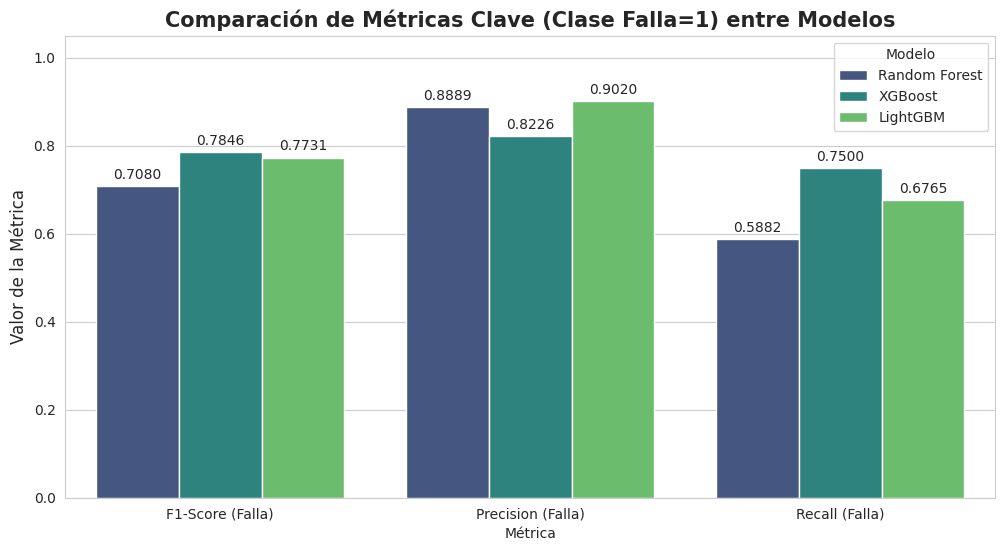

In [61]:
# Función para extraer las métricas clave del Reporte de Clasificación
def extract_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Modelo': model_name,
        # Precision, Recall y F1-Score para la clase minoritaria (Fallo = 1)
        'Precision (Falla)': report['1']['precision'],
        'Recall (Falla)': report['1']['recall'],
        'F1-Score (Falla)': report['1']['f1-score'],
        # Accuracy global
        'Accuracy': report['accuracy']
    }

# 1. Extraer métricas de los 3 modelos
rf_metrics = extract_metrics(y_test, y_pred_best, 'Random Forest')
xgb_metrics = extract_metrics(y_test, y_pred_xgb_best, 'XGBoost')
lgbm_metrics = extract_metrics(y_test, y_pred_lgbm_best, 'LightGBM')

# 2. Crear el DataFrame de comparación
comparison_df = pd.DataFrame([rf_metrics, xgb_metrics, lgbm_metrics])

# 3. Mostrar la tabla de resultados
print("\n TABLA DE COMPARACIÓN FINAL")
comparison_df_formatted = comparison_df.set_index('Modelo').style.background_gradient(cmap='YlGnBu').format('{:.4f}')
display(comparison_df_formatted) # Usamos display si estamos en un notebook

# 4. Crear el gráfico de comparación de F1-Score (la métrica clave para desbalance)
comparison_melt = pd.melt(comparison_df, id_vars='Modelo', value_vars=['F1-Score (Falla)', 'Precision (Falla)', 'Recall (Falla)'],
                          var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(x='Métrica', y='Valor', hue='Modelo', data=comparison_melt, palette='viridis')
plt.title('Comparación de Métricas Clave (Clase Falla=1) entre Modelos', fontsize=15, fontweight='bold')
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Modelo')

# Anotar los valores exactos
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.4f', padding=3)

plt.show()